/tmp/ipykernel_36701/2777322829.py:14: RuntimeWarning: invalid value encountered in sqrt
  dist = np.sqrt(np.sum(diff**2, axis=2))  # shape (h, w)


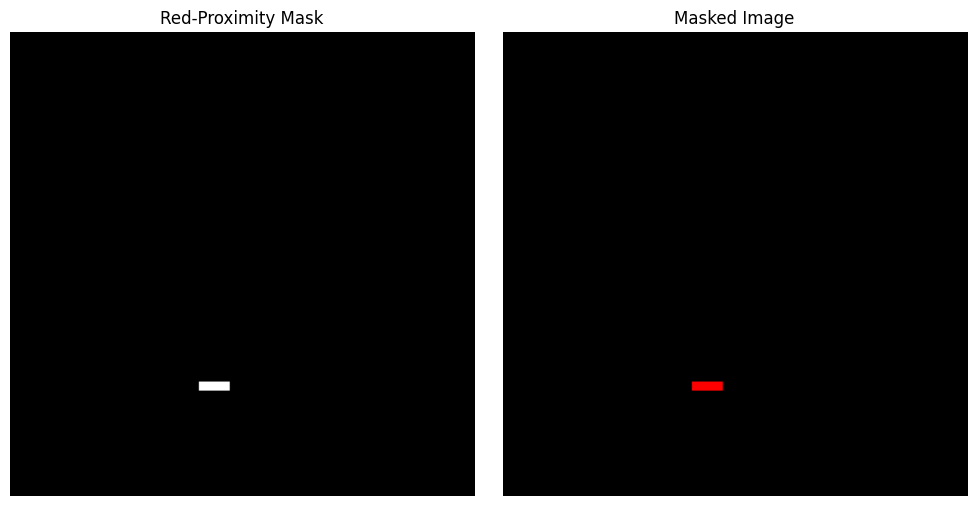

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

# (after you’ve computed `mask` and `masked` as above)
# Load your image
img = cv2.imread('40031.png')  # BGR format

# Define the target red color in BGR
target = np.array([0, 0, 255], dtype=np.int16)

# Compute per-pixel Euclidean distance from the target color
diff = img.astype(np.int16) - target  # shape (h, w, 3)
dist = np.sqrt(np.sum(diff**2, axis=2))  # shape (h, w)

# Threshold: keep pixels within this distance of pure red
max_dist = 0  # adjust: lower = more strict, higher = more lenient
mask = (dist <= max_dist).astype(np.uint8) * 255  # binary mask

# Apply mask
masked = cv2.bitwise_and(img, img, mask=mask)

# Convert BGR→RGB for correct color display
masked_rgb = cv2.cvtColor(masked, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Show the binary mask
axes[0].imshow(mask, cmap='gray')
axes[0].set_title('Red-Proximity Mask')
axes[0].axis('off')

# Show the masked image
axes[1].imshow(masked_rgb)
axes[1].set_title('Masked Image')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [32]:
import os
import cv2
import numpy as np
from glob import glob
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from skimage.measure import moments, moments_hu
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
import matplotlib.pyplot as plt

# 1. CONFIG
IMG_DIR       = "../data/Tell2Design Data/General Data/floorplan_reoriented"
# N_CLUSTERS    = 10
SAVE_LABELS   = "plan_labels.csv"
OUTPUT_CSV    = "extracted_features.csv"

# 2. COLOR DEFINITIONS (BGR in OpenCV)
LIVING_COLOR = (0xAA, 0xE8, 0xEE)  # given as (R,G,B); flip to (B,G,R)
ENTRANCE_COLOR= (0,0,255)                 # pure red
# We assume everything non-white/non-red/non-living is “outer wall” 
# (or you could detect the black border via Canny+findContours)

def extract_masks(img):
    """
    Return:
      - outer_mask: interior of the main wall boundary (white), exterior is black.
      - living_mask: binary mask of living-room region.
      - entrance_mask: binary mask of red entrance pixels.
    """
    # 1) Living-room mask
    living_mask   = cv2.inRange(img, np.array(LIVING_COLOR), np.array(LIVING_COLOR))

    # 2) Entrance mask
    entrance_mask = cv2.inRange(img, np.array(ENTRANCE_COLOR), np.array(ENTRANCE_COLOR))

    # 3) Wall boundary mask: black walls + entrance
    #    - walls: pixels that are (0,0,0) in BGR
    wall_mask = cv2.inRange(img, np.array([0,0,0]), np.array([0,0,0]))
    boundary_mask = cv2.bitwise_or(wall_mask, entrance_mask)

    # 4) Find largest closed contour of boundary
    #    a) find all contours in the boundary mask
    contours, _ = cv2.findContours(boundary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    #    b) pick the largest by area
    if contours:
        main_contour = max(contours, key=cv2.contourArea)
        # 5) Fill the contour to get the interior
        interior_mask = np.zeros_like(boundary_mask)
        cv2.drawContours(interior_mask, [main_contour], -1, color=255, thickness=cv2.FILLED)
        outer_mask = interior_mask  # white = interior, black = exterior
    else:
        # Fallback: treat whole image as interior
        outer_mask = np.ones_like(boundary_mask) * 255

    return outer_mask, living_mask, entrance_mask

def hu_vector(mask):
    """Compute first 7 Hu moments of a binary mask, log-transformed."""
    m = moments(mask.astype(np.uint8), order=3)
    hu = moments_hu(m)
    # log‐scale to reduce dynamic range
    return -np.sign(hu) * np.log10(np.abs(hu) + 1e-12)

def entrance_centroid(mask):
    """Return (x,y) of red entrance pixels, normalized to [0,1]."""
    ys, xs = np.where(mask>0)
    if len(xs)==0:
        return (np.nan, np.nan)
    x_mean = xs.mean()/mask.shape[1]
    y_mean = ys.mean()/mask.shape[0]
    return (x_mean, y_mean)

In [33]:
import pandas as pd

In [34]:
img = cv2.imread("../data/Tell2Design Data/General Data/floorplan_reoriented/1000.png")
outer, living, entr = extract_masks(img)

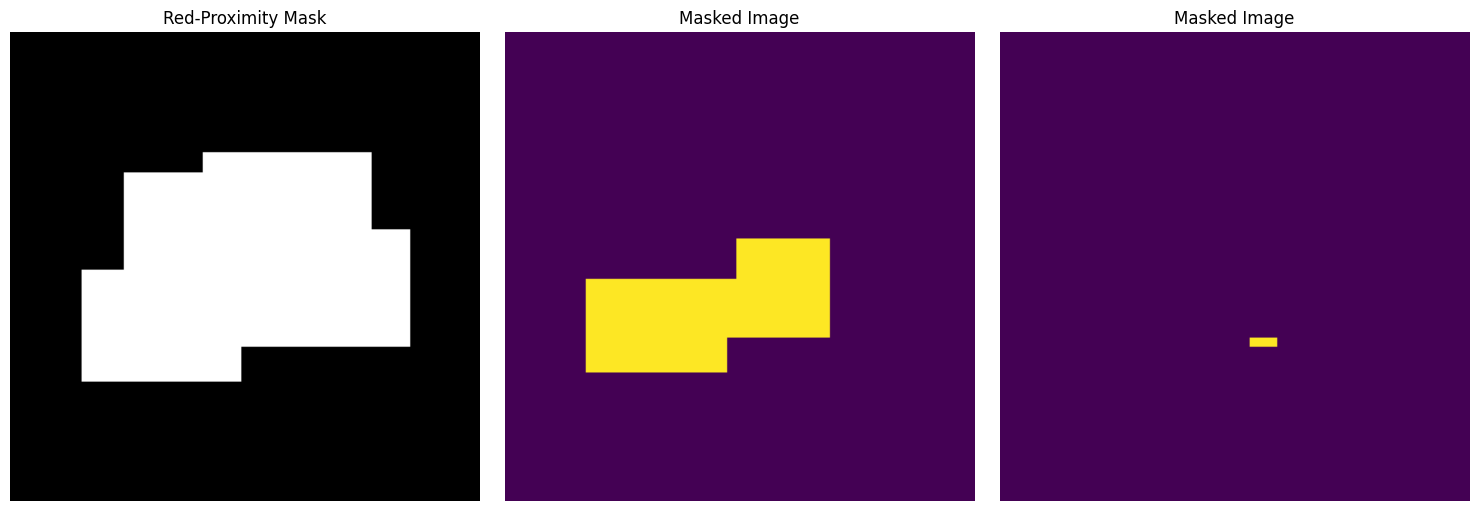

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Show the binary mask
axes[0].imshow(outer, cmap='gray')
axes[0].set_title('Red-Proximity Mask')
axes[0].axis('off')

# Show the masked image
axes[1].imshow(living)
axes[1].set_title('Masked Image')
axes[1].axis('off')

axes[2].imshow(entr)
axes[2].set_title('Masked Image')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [37]:
records = []
files = sorted(glob(os.path.join(IMG_DIR, "*.png")))

for fn in files:
    img = cv2.imread(fn)
    outer, living, entr = extract_masks(img)
    hu_outer  = hu_vector(outer)
    hu_living = hu_vector(living)
    ex, ey     = entrance_centroid(entr)
    
    record = {
        "filename": os.path.basename(fn),
        "entrance_x": ex,
        "entrance_y": ey,
    }
    # add hu_outer dims
    for i, val in enumerate(hu_outer, 1):
        record[f"hu_outer_{i}"] = val
    # add hu_living dims
    for i, val in enumerate(hu_living, 1):
        record[f"hu_living_{i}"] = val
    
    records.append(record)

# === SAVE TO CSV ===
df = pd.DataFrame.from_records(records)
df.to_csv(OUTPUT_CSV, index=False)

4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30


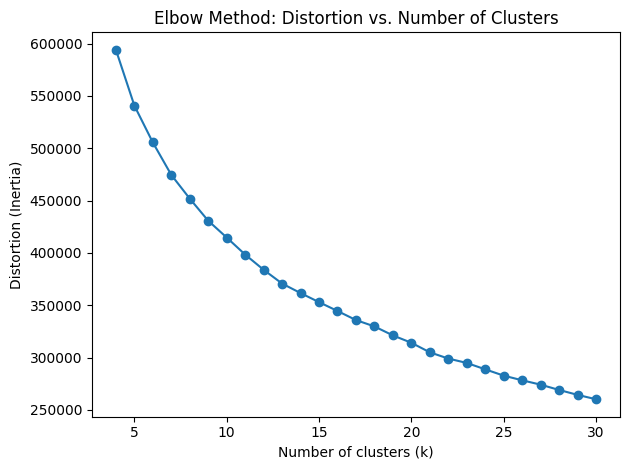

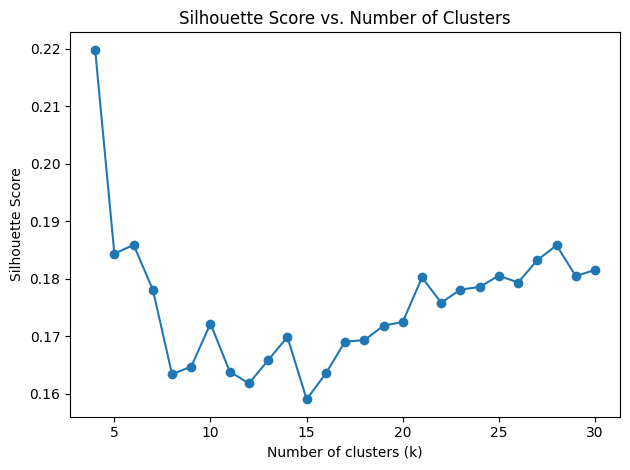

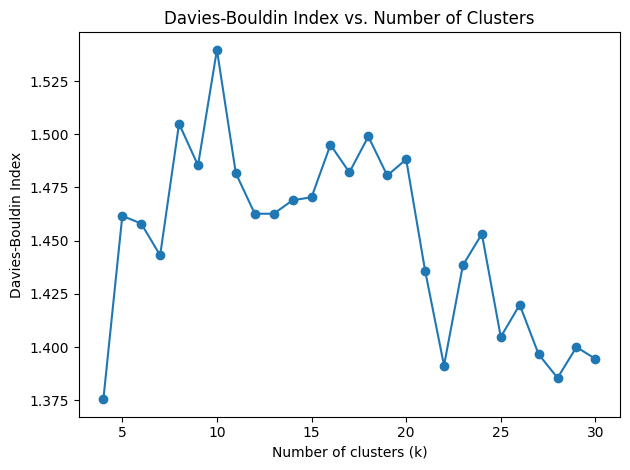

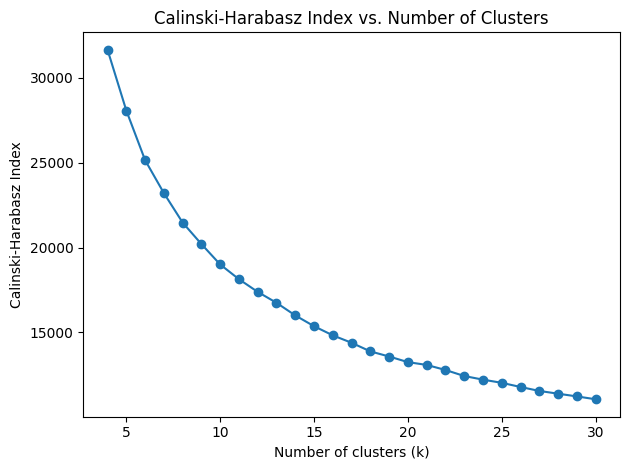

Evaluation complete for k in [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]


In [38]:
FEATURE_CSV = "extracted_features.csv"
K_RANGE = range(4, 31)

# === LOAD FEATURES ===
df = pd.read_csv(FEATURE_CSV)
feature_cols = [c for c in df.columns if c.startswith("hu_outer_") or c.startswith("hu_living_") or c in ("entrance_x", "entrance_y")]
X = df[feature_cols].values

# Handle NaNs in entrance by imputing 0.5 (center)
nan_mask = np.isnan(X)
X[nan_mask] = 0.5

# === STANDARDIZE FEATURES ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === CLUSTERING EVALUATION ===
inertias = []
silhouettes = []
db_indices = []
ch_indices = []

for k in K_RANGE:
    print(k)
    kmeans = KMeans(n_clusters=k, random_state=0)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    db_indices.append(davies_bouldin_score(X_scaled, labels))
    ch_indices.append(calinski_harabasz_score(X_scaled, labels))

# === PLOTTING ===
# 1. Distortion (Inertia) Plot
plt.figure()
plt.plot(list(K_RANGE), inertias, marker='o')
plt.title("Elbow Method: Distortion vs. Number of Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Distortion (Inertia)")
plt.tight_layout()
plt.show()

# 2. Silhouette Score Plot
plt.figure()
plt.plot(list(K_RANGE), silhouettes, marker='o')
plt.title("Silhouette Score vs. Number of Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

# 3. Davies-Bouldin Index Plot
plt.figure()
plt.plot(list(K_RANGE), db_indices, marker='o')
plt.title("Davies-Bouldin Index vs. Number of Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Davies-Bouldin Index")
plt.tight_layout()
plt.show()

# 4. Calinski-Harabasz Index Plot
plt.figure()
plt.plot(list(K_RANGE), ch_indices, marker='o')
plt.title("Calinski-Harabasz Index vs. Number of Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Calinski-Harabasz Index")
plt.tight_layout()
plt.show()

print("Evaluation complete for k in", list(K_RANGE))

30
32
34
36
38
40
42
44
46
48


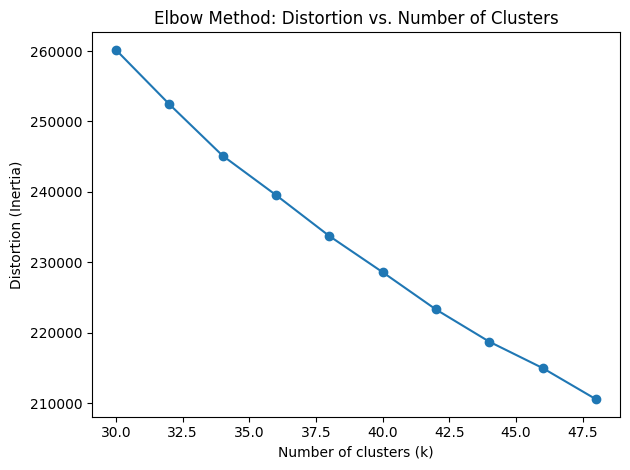

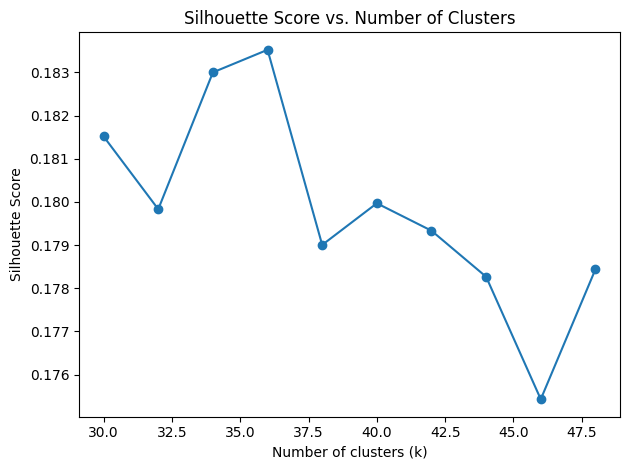

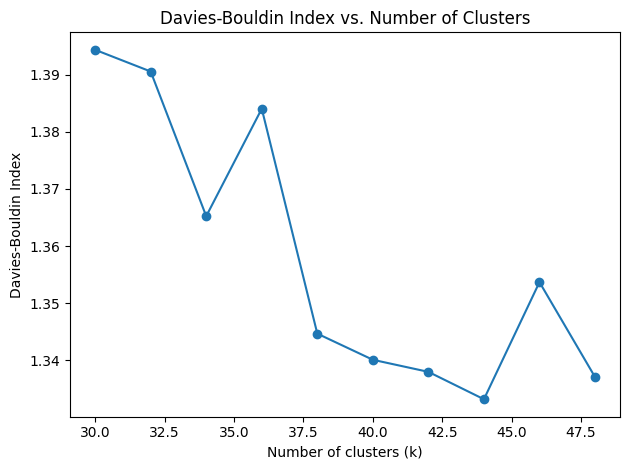

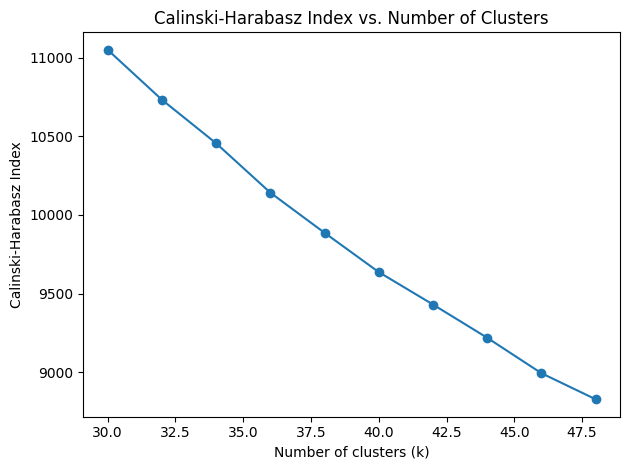

Evaluation complete for k in [30, 32, 34, 36, 38, 40, 42, 44, 46, 48]


In [ ]:
FEATURE_CSV = "extracted_features.csv"
K_RANGE = range(30, 50, 2)

# === LOAD FEATURES ===
df = pd.read_csv(FEATURE_CSV)
feature_cols = [c for c in df.columns if c.startswith("hu_outer_") or c.startswith("hu_living_") or c in ("entrance_x", "entrance_y")]
X = df[feature_cols].values

# Handle NaNs in entrance by imputing 0.5 (center)
nan_mask = np.isnan(X)
X[nan_mask] = 0.5

# === STANDARDIZE FEATURES ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === CLUSTERING EVALUATION ===
inertias = []
silhouettes = []
db_indices = []
ch_indices = []

for k in K_RANGE:
    print(k)
    kmeans = KMeans(n_clusters=k, random_state=0)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    db_indices.append(davies_bouldin_score(X_scaled, labels))
    ch_indices.append(calinski_harabasz_score(X_scaled, labels))

# === PLOTTING ===
# 1. Distortion (Inertia) Plot
plt.figure()
plt.plot(list(K_RANGE), inertias, marker='o')
plt.title("Elbow Method: Distortion vs. Number of Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Distortion (Inertia)")
plt.tight_layout()
plt.show()

# 2. Silhouette Score Plot
plt.figure()
plt.plot(list(K_RANGE), silhouettes, marker='o')
plt.title("Silhouette Score vs. Number of Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

# 3. Davies-Bouldin Index Plot
plt.figure()
plt.plot(list(K_RANGE), db_indices, marker='o')
plt.title("Davies-Bouldin Index vs. Number of Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Davies-Bouldin Index")
plt.tight_layout()
plt.show()

# 4. Calinski-Harabasz Index Plot
plt.figure()
plt.plot(list(K_RANGE), ch_indices, marker='o')
plt.title("Calinski-Harabasz Index vs. Number of Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Calinski-Harabasz Index")
plt.tight_layout()
plt.show()

print("Evaluation complete for k in", list(K_RANGE))

50
55
60
65
70
75
80
85
90
95


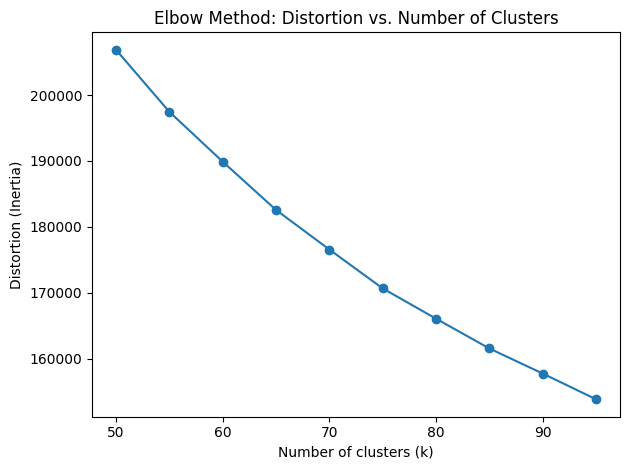

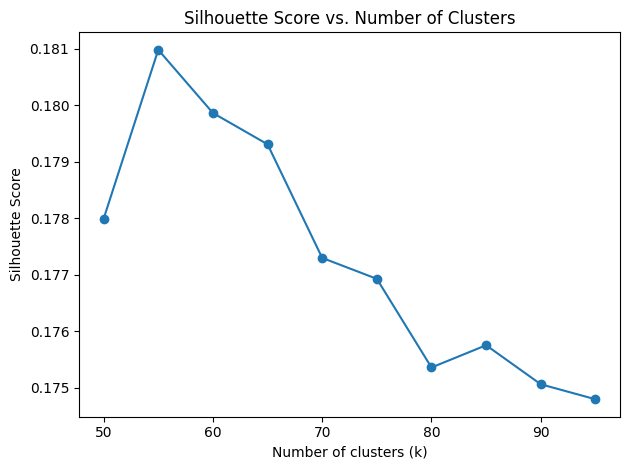

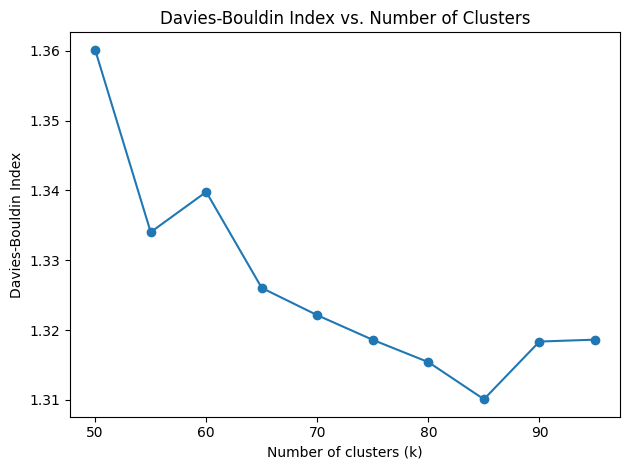

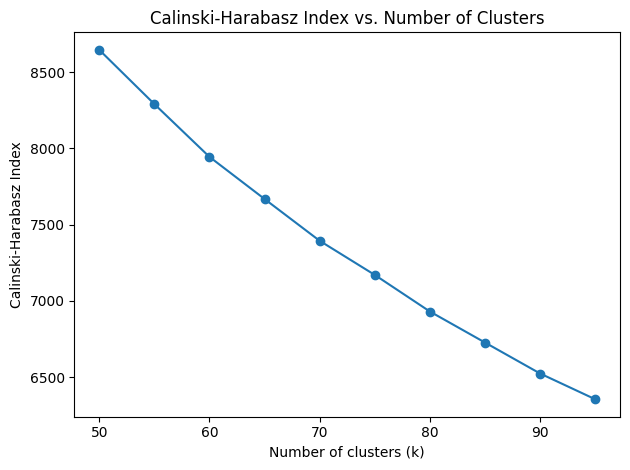

Evaluation complete for k in [50, 55, 60, 65, 70, 75, 80, 85, 90, 95]


In [40]:
FEATURE_CSV = "extracted_features.csv"
K_RANGE = range(50, 100, 5)

# === LOAD FEATURES ===
df = pd.read_csv(FEATURE_CSV)
feature_cols = [c for c in df.columns if c.startswith("hu_outer_") or c.startswith("hu_living_") or c in ("entrance_x", "entrance_y")]
X = df[feature_cols].values

# Handle NaNs in entrance by imputing 0.5 (center)
nan_mask = np.isnan(X)
X[nan_mask] = 0.5

# === STANDARDIZE FEATURES ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === CLUSTERING EVALUATION ===
inertias = []
silhouettes = []
db_indices = []
ch_indices = []

for k in K_RANGE:
    print(k)
    kmeans = KMeans(n_clusters=k, random_state=0)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    db_indices.append(davies_bouldin_score(X_scaled, labels))
    ch_indices.append(calinski_harabasz_score(X_scaled, labels))

# === PLOTTING ===
# 1. Distortion (Inertia) Plot
plt.figure()
plt.plot(list(K_RANGE), inertias, marker='o')
plt.title("Elbow Method: Distortion vs. Number of Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Distortion (Inertia)")
plt.tight_layout()
plt.show()

# 2. Silhouette Score Plot
plt.figure()
plt.plot(list(K_RANGE), silhouettes, marker='o')
plt.title("Silhouette Score vs. Number of Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

# 3. Davies-Bouldin Index Plot
plt.figure()
plt.plot(list(K_RANGE), db_indices, marker='o')
plt.title("Davies-Bouldin Index vs. Number of Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Davies-Bouldin Index")
plt.tight_layout()
plt.show()

# 4. Calinski-Harabasz Index Plot
plt.figure()
plt.plot(list(K_RANGE), ch_indices, marker='o')
plt.title("Calinski-Harabasz Index vs. Number of Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Calinski-Harabasz Index")
plt.tight_layout()
plt.show()

print("Evaluation complete for k in", list(K_RANGE))

100
105
110
115
120
125
130
135
140
145
150
155
160
165
170
175
180
185
190
195


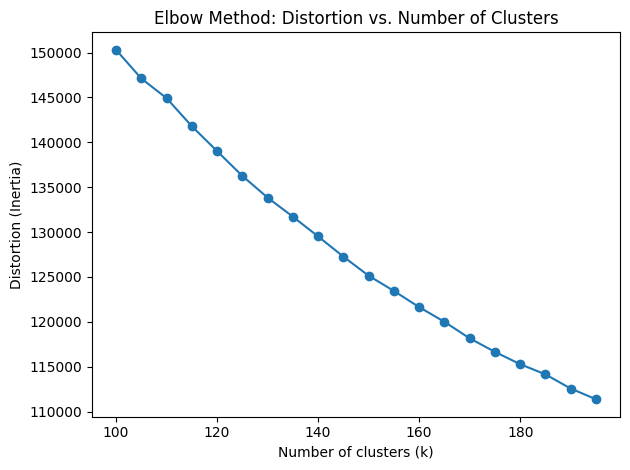

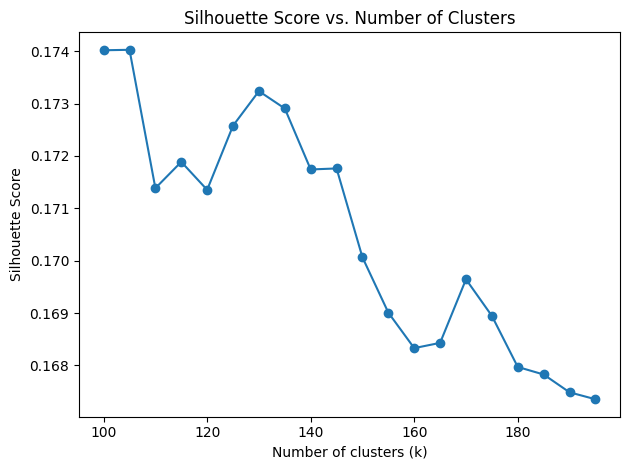

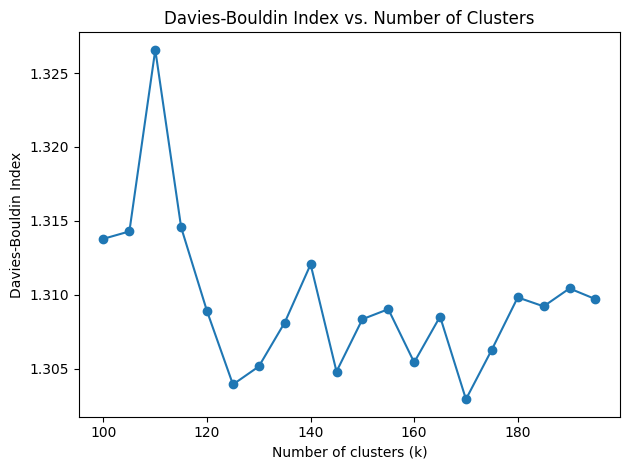

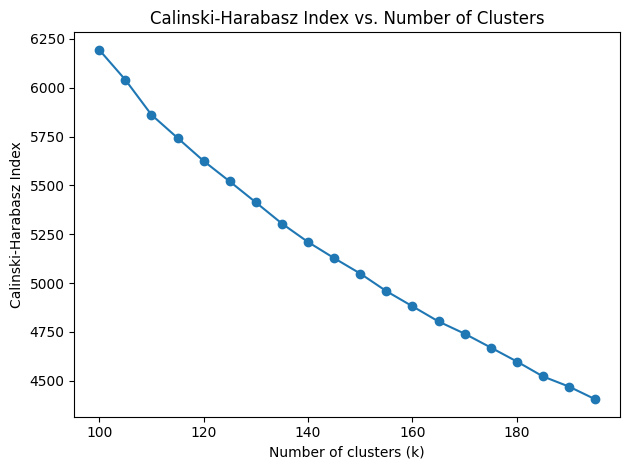

Evaluation complete for k in [100, 105, 110, 115, 120, 125, 130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190, 195]


In [41]:
FEATURE_CSV = "extracted_features.csv"
K_RANGE = range(100, 200, 5)

# === LOAD FEATURES ===
df = pd.read_csv(FEATURE_CSV)
feature_cols = [c for c in df.columns if c.startswith("hu_outer_") or c.startswith("hu_living_") or c in ("entrance_x", "entrance_y")]
X = df[feature_cols].values

# Handle NaNs in entrance by imputing 0.5 (center)
nan_mask = np.isnan(X)
X[nan_mask] = 0.5

# === STANDARDIZE FEATURES ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === CLUSTERING EVALUATION ===
inertias = []
silhouettes = []
db_indices = []
ch_indices = []

for k in K_RANGE:
    print(k)
    kmeans = KMeans(n_clusters=k, random_state=0)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    db_indices.append(davies_bouldin_score(X_scaled, labels))
    ch_indices.append(calinski_harabasz_score(X_scaled, labels))

# === PLOTTING ===
# 1. Distortion (Inertia) Plot
plt.figure()
plt.plot(list(K_RANGE), inertias, marker='o')
plt.title("Elbow Method: Distortion vs. Number of Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Distortion (Inertia)")
plt.tight_layout()
plt.show()

# 2. Silhouette Score Plot
plt.figure()
plt.plot(list(K_RANGE), silhouettes, marker='o')
plt.title("Silhouette Score vs. Number of Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

# 3. Davies-Bouldin Index Plot
plt.figure()
plt.plot(list(K_RANGE), db_indices, marker='o')
plt.title("Davies-Bouldin Index vs. Number of Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Davies-Bouldin Index")
plt.tight_layout()
plt.show()

# 4. Calinski-Harabasz Index Plot
plt.figure()
plt.plot(list(K_RANGE), ch_indices, marker='o')
plt.title("Calinski-Harabasz Index vs. Number of Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Calinski-Harabasz Index")
plt.tight_layout()
plt.show()

print("Evaluation complete for k in", list(K_RANGE))

In [42]:
best_k = 28
kmeans = KMeans(n_clusters=best_k, random_state=0)
labels = kmeans.fit_predict(X_scaled)

In [43]:
df['labels'] = labels

In [44]:
df

,filename,entrance_x,entrance_y,hu_outer_1,hu_outer_2,hu_outer_3,hu_outer_4,hu_outer_5,hu_outer_6,hu_outer_7,hu_living_1,hu_living_2,hu_living_3,hu_living_4,hu_living_5,hu_living_6,hu_living_7,labels
0,0.png,0.824219,0.648438,-11.223071,-22.346588,-26.827814,-27.012615,-53.932505,-38.185676,-52.519831,-10.926537,-21.800556,-26.374372,-26.479349,-52.906190,-37.379346,-50.887348,3
1,1.png,0.187500,0.542969,-11.390951,-22.687739,-27.231797,-27.407854,-54.727670,-38.751703,-52.551520,-11.060700,-22.057987,-26.636394,-26.764164,-53.464430,-37.792967,-51.359874,8
2,10.png,0.214844,0.757812,-11.291601,-22.488751,-26.999999,-27.178651,-54.267964,-38.422990,-52.137673,-10.835283,-21.627810,-26.135727,-26.220586,-52.398743,-37.034477,49.358181,4
3,100.png,0.601562,0.644531,-11.317713,-22.482487,-26.897647,-27.191206,-54.234603,-38.432233,-53.073083,-10.868555,-21.630243,-26.118239,-26.309832,-52.523266,-37.123871,-51.245080,5
4,1000.png,0.558594,0.660156,-11.215142,-22.329877,-26.818228,-27.009165,-53.922588,-38.174011,-52.472759,-10.810414,-21.552356,-26.050330,-26.186831,-52.305390,-36.962902,-50.314119,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80782,9995.png,0.492188,0.742188,-11.330961,-22.518356,-26.964319,-27.240341,-54.342221,-38.499219,-53.000478,-10.811506,-21.586953,-26.137228,-26.208740,-52.381724,-37.002180,-49.417862,5
80783,9996.png,0.378906,0.796875,-11.260103,-22.403984,-26.861943,-27.095413,-54.074091,-38.297405,-51.260809,-10.809989,-21.598351,-26.231687,-26.275089,-52.528476,-37.074256,-49.910632,6
80784,9997.png,0.589844,0.675781,-11.222038,-22.349240,-26.842795,-27.023376,-53.956314,-38.197897,-52.372531,-10.669731,-21.303855,-25.842230,-25.913463,-51.791309,-36.565380,-47.959384,1
80785,9998.png,0.609375,0.726562,-11.291706,-22.501550,-27.025058,-27.181078,-54.284121,-38.431840,-52.313660,-10.701658,-21.382506,-25.929207,-25.967397,-51.915699,-36.658647,48.633653,4


In [45]:
df.to_csv("shape_clustering_results.csv", index=False)

In [46]:
nnary_features = pd.read_csv("./nnary_features_40000.csv")['filename']

In [49]:
df.merge(nnary_features, how="inner", on="filename")[:1000].to_csv("shape_clustering_results_1000.csv", index=False)